# Аналіз результатів опитування Stack Overflow Developer Survey 2025
**Мета:** Проаналізувати демографічні дані, зарплати, умови праці та вподобання розробників.

In [2]:
import pandas as pd
import numpy as np

# Завантаження датасетів
try:
    df = pd.read_csv('survey_results_public.csv')
    schema = pd.read_csv('survey_results_schema.csv')
    print("Дані успішно завантажено!")
    print(f"Розмір основного датасету: {df.shape}")
except FileNotFoundError:
    print("Файл не знайдено. Перевір шлях до файлу.")

# Налаштування відображення (щоб бачити всі колонки при виведенні)
pd.set_option('display.max_columns', None)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Дані успішно завантажено!
Розмір основного датасету: (49191, 172)


/var/folders/jc/7t4gh1n966z2gtvw28sm7rsc0000gn/T/ipykernel_51745/3970271448.py:7: DtypeWarning: Columns (56,74,92,97,98,105,109,110,132,162,165) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('survey_results_public.csv')


## Завдання 1. Визначення кількості респондентів
Визначимо загальну кількість учасників опитування.

In [3]:
total_respondents = df.shape[0]
print(f"Всього респондентов: {total_respondents}")

Всього респондентов: 49191


## Завдання 2. Аналіз повноти даних
Знайдемо кількість респондентів, які відповіли на **всі** запитання опитування.

In [4]:
# 1. Отримуємо список всіх питань зі схеми (поле 'qname')
question_columns = set(schema['qname']) 

# 2. Знаходимо перетин з колонками основного датасету
existing_columns = set(df.columns)
target_columns = list(question_columns.intersection(existing_columns))

# 3. Фільтруємо датасет по цих колонках і видаляємо рядки з пропусками
complete_responses = df[target_columns].dropna()
count_complete = complete_responses.shape[0]

print(f"Кількість респондентів, що відповіли на ВСІ запитання: {count_complete}")

Кількість респондентів, що відповіли на ВСІ запитання: 0


## Завдання 3. Статистичний аналіз досвіду роботи
Обчислимо міри центральної тенденції для поля `WorkExp` (досвід роботи).

In [5]:
work_exp_col = 'WorkExp'

# Обчислення метрик
mean_exp = df[work_exp_col].mean()
median_exp = df[work_exp_col].median()
mode_exp = df[work_exp_col].mode()[0] # mode повертає серію, беремо перший елемент

print(f"Середній досвід роботи: {mean_exp:.2f} років")
print(f"Медіанний досвід: {median_exp} років")
print(f"Мода (найчастіше зустрічається): {mode_exp} років")

Середній досвід роботи: 13.37 років
Медіанний досвід: 10.0 років
Мода (найчастіше зустрічається): 10.0 років


## Завдання 4. Віддалена робота
Визначимо кількість респондентів, які працюють віддалено (`Remote`).

In [8]:
remote_workers = df[df['RemoteWork'] == 'Remote'] 
remote_count = remote_workers.shape[0]

print(f"Кількість респондентів, що працюють віддалено: {remote_count}")

Кількість респондентів, що працюють віддалено: 10931


## Завдання 5. Популярність Python
Визначимо відсоток респондентів, які використовують Python у своїй роботі.

In [9]:
# Шукаємо 'Python' у колонці мов. na=False ігнорує порожні значення.
python_users = df[df['LanguageHaveWorkedWith'].str.contains('Python', na=False, regex=False)]
python_count = python_users.shape[0]

# Розрахунок відсотка
python_percentage = (python_count / total_respondents) * 100

print(f"Відсоток респондентів, які програмують на Python: {python_percentage:.2f}%")

Відсоток респондентів, які програмують на Python: 37.54%


## Завдання 6. Аналіз способів навчання
Скільки респондентів навчалися програмувати за допомогою онлайн-курсів?

In [10]:
# Перевір назву колонки: часто це 'LearnCode' або 'LearnCodeOnline'
online_learners = df[df['LearnCode'].str.contains('Online Courses', na=False, regex=False)]
online_count = online_learners.shape[0]

print(f"Кількість респондентів, що навчалися на онлайн-курсах: {online_count}")

Кількість респондентів, що навчалися на онлайн-курсах: 10973


## Завдання 7. Географічний аналіз зарплат Python-розробників
Розрахуємо середню та медіанну річну компенсацію (`ConvertedCompYearly`) для розробників Python у розрізі країн.

In [11]:
# Використовуємо вже відфільтрований датафрейм python_users
salary_stats = python_users.groupby('Country')['ConvertedCompYearly'].agg(['mean', 'median'])

# Округлюємо значення
salary_stats = salary_stats.round(2)

# Перейменовуємо колонки українською
salary_stats.columns = ['Середня ЗП ($)', 'Медіанна ЗП ($)']

# Виводимо Топ-10 країн за медіанною зарплатою
print("Топ-10 країн за зарплатами Python-розробників:")
display(salary_stats.sort_values(by='Медіанна ЗП ($)', ascending=False).head(10))

Топ-10 країн за зарплатами Python-розробників:


,Середня ЗП ($),Медіанна ЗП ($)
Country,,
Oman,390135.00,390135.0
Andorra,226103.50,226103.5
United States of America,173298.59,150000.0
Israel,135828.37,142594.0
Switzerland,156456.60,142592.0
Nomadic,120131.57,139218.0
Ireland,120523.92,116015.0
Luxembourg,116014.71,109054.0
Kyrgyzstan,106008.50,106008.5


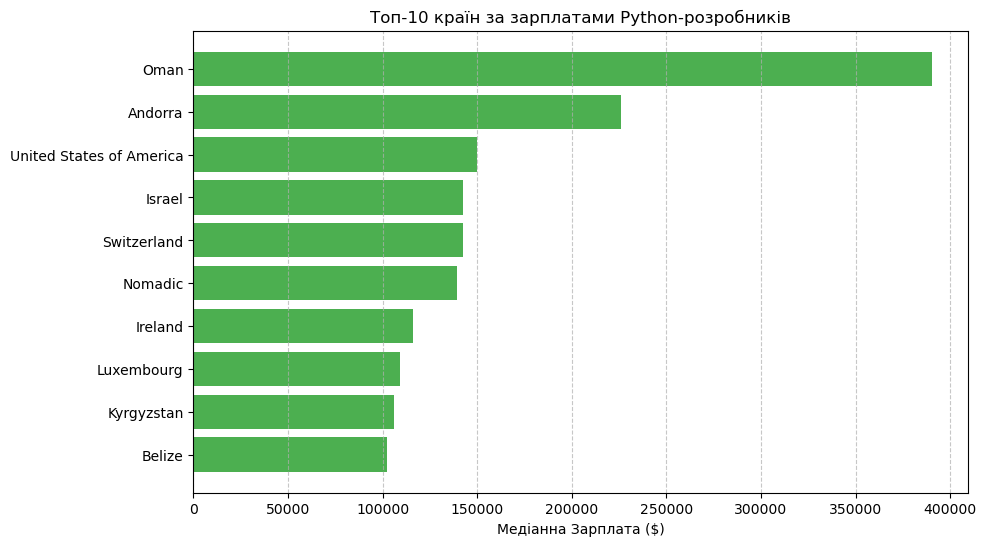

In [18]:
import matplotlib.pyplot as plt

# 1. Беремо топ-10 країн із найвищою медіанною зарплатою
# (Сортуємо за спаданням і беремо верхні 10)
top_10 = salary_stats.sort_values(by='Медіанна ЗП ($)', ascending=False).head(10)

# 2. Сортуємо їх у зворотному порядку для красивого відображення на графіку
# (щоб країна з найбільшою зарплатою була зверху)
top_10_plot = top_10.sort_values(by='Медіанна ЗП ($)', ascending=True)

# 3. Будуємо графік
plt.figure(figsize=(10, 6))
plt.barh(top_10_plot.index, top_10_plot['Медіанна ЗП ($)'], color='#4CAF50') # Зробимо зеленим :)

# Підписи
plt.xlabel('Медіанна Зарплата ($)')
plt.title('Топ-10 країн за зарплатами Python-розробників')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Показати
plt.show()

## Завдання 8. Рівень освіти топ-5 фахівців з найвищою зарплатою
Яку освіту мають 5 респондентів із найбільшою компенсацією?

In [12]:
# Сортуємо за спаданням зарплати та беремо перші 5 записів
top_earners = df.sort_values(by='ConvertedCompYearly', ascending=False).head(5)

# Вибираємо колонки рівня освіти (EdLevel) та зарплати
top_education = top_earners[['EdLevel', 'ConvertedCompYearly']]

print("Рівень освіти 5 респондентів з найвищою зарплатою:")
display(top_education)

Рівень освіти 5 респондентів з найвищою зарплатою:


,EdLevel,ConvertedCompYearly
34267,"Associate degree (A.A., A.S., etc.)",50000000.0
28700,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",33552715.0
43143,"Associate degree (A.A., A.S., etc.)",18387548.0
35353,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",15430267.0
45971,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",13921760.0


## Завдання 9. Популярність Python серед різних вікових категорій

In [13]:
# Групуємо за віком
age_groups = df.groupby('Age')

# Функція для підрахунку відсотка користувачів Python у групі
def count_python_percent(group):
    python_in_group = group['LanguageHaveWorkedWith'].str.contains('Python', na=False, regex=False).sum()
    total_in_group = len(group)
    return (python_in_group / total_in_group) * 100

# Застосовуємо функцію до груп
python_by_age = age_groups.apply(count_python_percent).reset_index(name='Python_Percent')

print("Популярність Python по вікових групах:")
display(python_by_age.sort_values(by='Python_Percent', ascending=False))

Популярність Python по вікових групах:


/var/folders/jc/7t4gh1n966z2gtvw28sm7rsc0000gn/T/ipykernel_51745/1278057650.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  python_by_age = age_groups.apply(count_python_percent).reset_index(name='Python_Percent')


,Age,Python_Percent
0,18-24 years old,40.000000
3,45-54 years old,38.629482
4,55-64 years old,37.242955
1,25-34 years old,36.939282
2,35-44 years old,36.719281
5,65 years or older,31.634820
6,Prefer not to say,31.216931


## Фінальне завдання. Аналіз індустрій для високооплачуваних віддалених фахівців
Визначимо найпоширеніші індустрії серед тих, хто працює віддалено та заробляє більше за 75% інших респондентів.

In [16]:
# 1. Рахуємо 75-й перцентиль зарплати
salary_threshold = df['ConvertedCompYearly'].quantile(0.75)
print(f"Поріг високих зарплат (top 25%): {salary_threshold} $")

# 2. Фільтруємо: ЗП > порогу ТА Тип роботи == Remote
high_income_remote = df[
    (df['ConvertedCompYearly'] > salary_threshold) & 
    (df['RemoteWork'] == 'Remote')
]

# 3. Рахуємо популярність індустрій
if 'Industry' in high_income_remote.columns:
    top_industries = high_income_remote['Industry'].value_counts().reset_index()
    top_industries.columns = ['Industry', 'Count']
    
    print("\nТоп індустрій серед високооплачуваних віддалених працівників:")
    display(top_industries.head(10))
else:
    print("Колонка 'Industry' не знайдена. Спробуй перевірити 'DevType'.")

Поріг високих зарплат (top 25%): 120596.0 $

Топ індустрій серед високооплачуваних віддалених працівників:


,Industry,Count
0,Software Development,1186
1,Fintech,190
2,Healthcare,188
3,Other:,176
4,"Internet, Telecomm or Information Services",138
5,Banking/Financial Services,88
6,Government,78
7,Media & Advertising Services,75
8,Retail and Consumer Services,65
9,"Transportation, or Supply Chain",63


### Загальні висновки

Проаналізувавши дані опитування Stack Overflow Developer Survey 2025, можна зробити наступні висновки:

1.  **Популярність Python:** Цю мову використовують **37.54%** респондентів. Найбільшу популярність вона має серед наймолодшої вікової групи (18-24 роки), де цей показник сягає **40%**.
2.  **Досвідченість спільноти:** Розробники, що взяли участь в опитуванні, є кваліфікованими фахівцями. Медіанний досвід роботи складає 10 років, а середній — понад 13 років.
3.  **Географія високих доходів:** Найвищі медіанні зарплати для Python-розробників зафіксовані в США ($150,000), Швейцарії ($142,592) та Ізраїлі. У топі опинилися малі країни (Оман, Андорра) через малу вибірку респондентів, але серед великих технологічних хабів лідирують США.
4.  **Елітна віддалена робота:** Поріг входження до 25% найбагатших розробників складає $120,596 на рік. Серед тих, хто працює віддалено з такою зарплатою, найбільше фахівців у сферах Software Development (традиційна розробка) та Fintech (фінансові технології).
5.  **Освіта:** Топ-5 фахівців з найвищими компенсаціями мають вищу освіту (рівень бакалавра або магістра), що підкреслює важливість фундаментальних знань для кар'єрного зростання.